<a href="https://colab.research.google.com/github/costpetrides/Air-pollution-COVID-19-impact/blob/main/Copy_of_Untitled1002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# $O_3$

/tmp/ipykernel_1443/2440800810.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["geometry"] = gdf.buffer(0.05)


Stations without country: 1


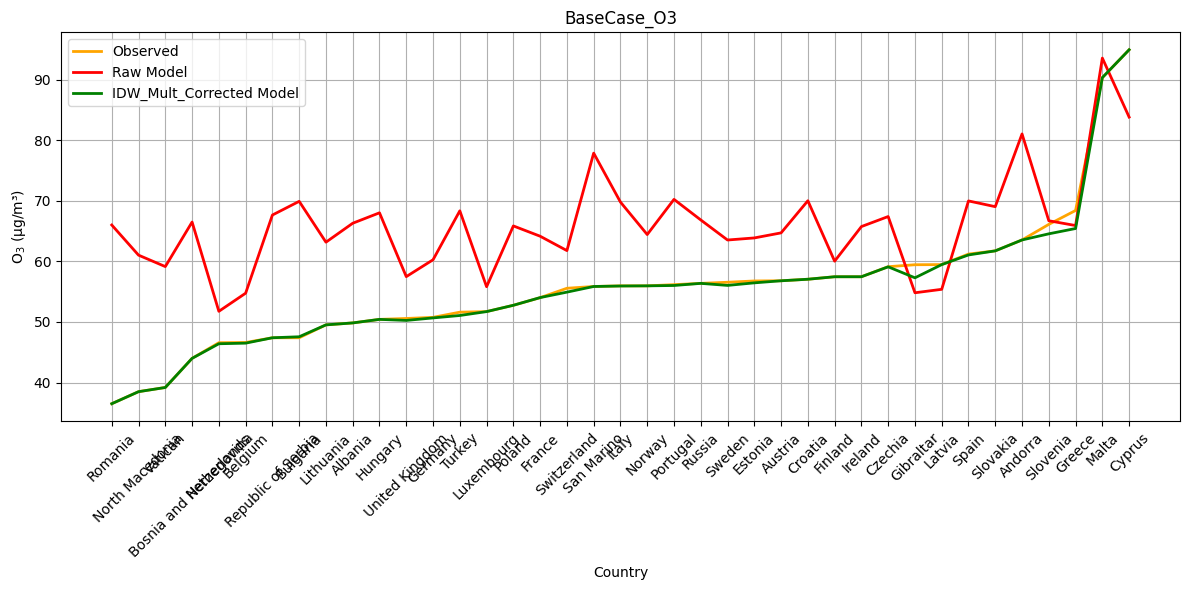


===== PERFORMANCE =====
RMSE Raw: 13.35
RMSE Corrected: 0.67
Bias Raw: 10.33
Bias Corrected: -0.25
RMSE Improvement: 95.02%


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_corr = xr.open_dataset("BaseCase_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_corr["lon"].values
lat = ds_corr["lat"].values

model_corr = ds_corr["SURF_ug_O3"].values
if model_corr.ndim == 3:
    model_corr = model_corr[0]

ds_corr.close()

ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")

model_raw = ds_raw["SURF_ug_O3"].values
if model_raw.ndim == 3:
    model_raw = model_raw[0]

ds_raw.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_O3_2015.csv")

# ✔ longitude safety
if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

# ======================================================
# 3. EXTRACT COUNTRY FROM STATION ID
# ======================================================
df["Country"] = df["Station"].str[:2]

# ======================================================
# 4. MAP STATIONS TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

model_corr_vals = []
model_raw_vals = []

for _, row in df.iterrows():
    j, i = find_idx(row["Longitude"], row["Latitude"])
    model_corr_vals.append(model_corr[j, i])
    model_raw_vals.append(model_raw[j, i])

df["Model_Corrected"] = model_corr_vals
df["Model_Raw"] = model_raw_vals

# ======================================================
# 5. GROUP BY COUNTRY
# ======================================================
grouped = df.groupby("Country")[["Average", "Model_Raw", "Model_Corrected"]].mean()

grouped = grouped.dropna()
grouped = grouped.sort_values("Average")

# ======================================================
# 6. PLOT
# ======================================================
x = np.arange(len(grouped))

plt.figure(figsize=(12, 6))

plt.plot(x, grouped["Average"], label="Observed", linewidth=2, color='green')
plt.plot(x, grouped["Model_Raw"], label="Raw Model", linewidth=2, color='red')
plt.plot(x, grouped["Model_Corrected"], label="Corrected Model", linewidth=2, color='orange')

plt.xticks(x, grouped.index, rotation=45)

plt.xlabel("Country")
plt.ylabel("NO$_2$ (μg/m³)")
plt.title("Scenario_2022_NO$_2$")

plt.legend()
plt.grid()
plt.ylim(0,40)
plt.tight_layout()
plt.show()

# ======================================================
# 7. PERFORMANCE METRICS
# ======================================================
obs = grouped["Average"].values
raw = grouped["Model_Raw"].values
corr = grouped["Model_Corrected"].values

rmse_raw = np.sqrt(np.mean((raw - obs)**2))
rmse_corr = np.sqrt(np.mean((corr - obs)**2))

bias_raw = np.mean(raw - obs)
bias_corr = np.mean(corr - obs)

print("\n===== PERFORMANCE =====")
print(f"RMSE Raw: {rmse_raw:.2f}")
print(f"RMSE Corrected: {rmse_corr:.2f}")
print(f"Bias Raw: {bias_raw:.2f}")
print(f"Bias Corrected: {bias_corr:.2f}")

improvement = 100 * (rmse_raw - rmse_corr) / rmse_raw
print(f"RMSE Improvement: {improvement:.2f}%")

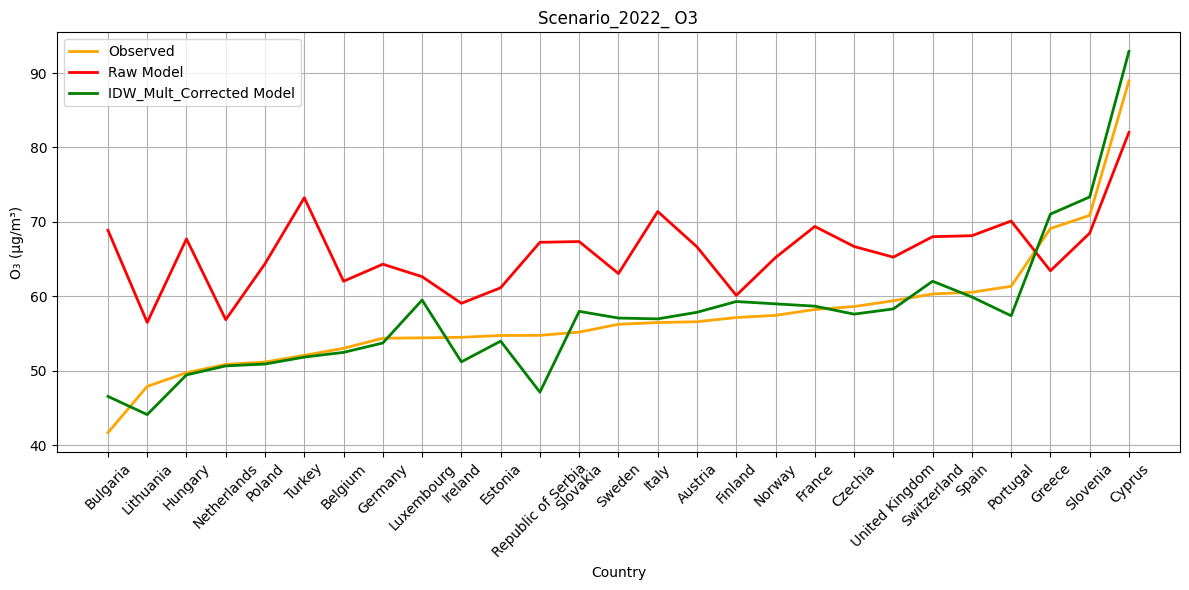


===== PERFORMANCE =====
RMSE Raw: 11.15
RMSE Corrected: 2.72
Bias Raw: 8.66
Bias Corrected: 0.19
RMSE Improvement: 75.64%


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# ======================================================
# 1. LOAD MODELS
# ======================================================
# Bias-corrected model
ds_corr = xr.open_dataset("Scen_2022_NKUA_O3_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_corr["lon"].values
lat = ds_corr["lat"].values

model_corr = ds_corr["SURF_ug_O3"].values
if model_corr.ndim == 3:
    model_corr = model_corr[0]

ds_corr.close()

# Raw model (before correction)
ds_raw = xr.open_dataset("EMEP_yearly_2022.nc")

model_raw = ds_raw["SURF_ug_O3"].values
if model_raw.ndim == 3:
    model_raw = model_raw[0]

ds_raw.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_O3_2022.csv")

geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# ======================================================
# 3. ASSIGN COUNTRIES (NO DOWNLOAD)
# ======================================================
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
world = world.to_crs("EPSG:4326")

gdf = gpd.sjoin(gdf, world[["geometry", "ADMIN"]], how="left", predicate="within")
gdf.rename(columns={"ADMIN": "Country"}, inplace=True)

# ======================================================
# 4. MAP STATIONS TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

model_corr_vals = []
model_raw_vals = []

for _, row in gdf.iterrows():
    j, i = find_idx(row["Longitude"], row["Latitude"])
    model_corr_vals.append(model_corr[j, i])
    model_raw_vals.append(model_raw[j, i])

gdf["Model_Corrected"] = model_corr_vals
gdf["Model_Raw"] = model_raw_vals

# ======================================================
# 5. GROUP BY COUNTRY
# ======================================================
grouped = gdf.groupby("Country")[["Average", "Model_Raw", "Model_Corrected"]].mean()

# remove stations without country
grouped = grouped.dropna()

# sort for better visualization
grouped = grouped.sort_values("Average")

# ======================================================
# 6. PLOT
# ======================================================
x = np.arange(len(grouped))

plt.figure(figsize=(12, 6))

plt.plot(x, grouped["Average"], label="Observed", linewidth=2, color='orange')
plt.plot(x, grouped["Model_Raw"], label="Raw Model", linewidth=2, color='red')
plt.plot(x, grouped["Model_Corrected"], label="IDW_Mult_Corrected Model", linewidth=2, color='green')

plt.xticks(x, grouped.index, rotation=45)

plt.xlabel("Country")
plt.ylabel("O₃ (μg/m³)")
plt.title("Scenario_2022_ O3")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ======================================================
# 7. PERFORMANCE METRICS
# ======================================================
obs = grouped["Average"].values
raw = grouped["Model_Raw"].values
corr = grouped["Model_Corrected"].values

# RMSE
rmse_raw = np.sqrt(np.mean((raw - obs)**2))
rmse_corr = np.sqrt(np.mean((corr - obs)**2))

# Bias
bias_raw = np.mean(raw - obs)
bias_corr = np.mean(corr - obs)

print("\n===== PERFORMANCE =====")
print(f"RMSE Raw: {rmse_raw:.2f}")
print(f"RMSE Corrected: {rmse_corr:.2f}")
print(f"Bias Raw: {bias_raw:.2f}")
print(f"Bias Corrected: {bias_corr:.2f}")

# improvement %
improvement = 100 * (rmse_raw - rmse_corr) / rmse_raw
print(f"RMSE Improvement: {improvement:.2f}%")

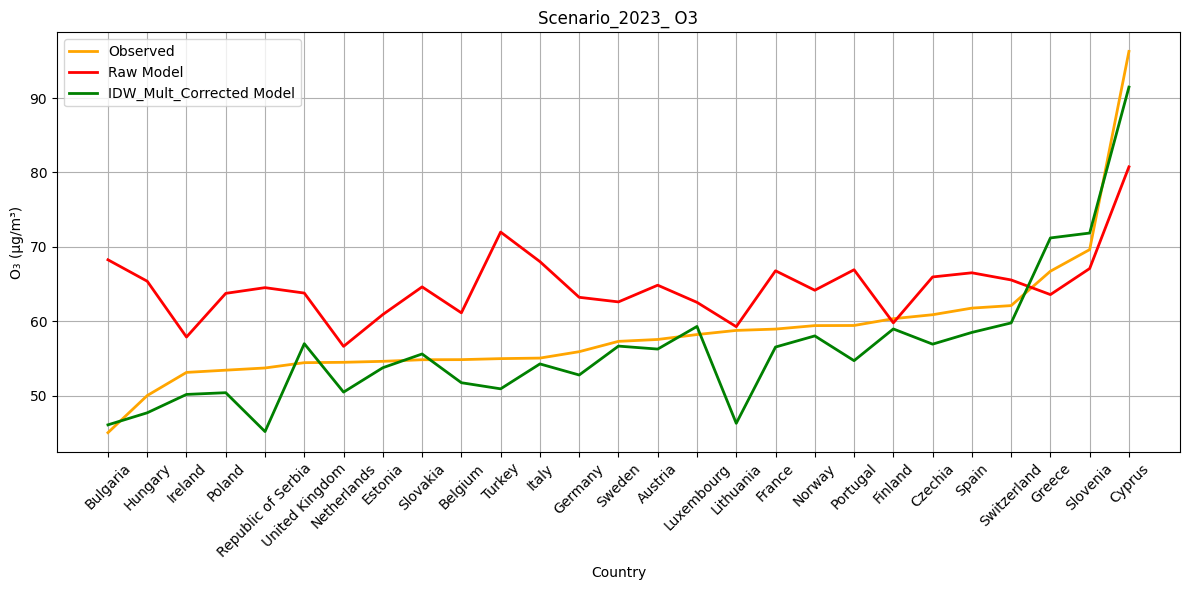


===== PERFORMANCE =====
RMSE Raw: 9.34
RMSE Corrected: 3.98
Bias Raw: 6.09
Bias Corrected: -2.19
RMSE Improvement: 57.36%


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# ======================================================
# 1. LOAD MODELS
# ======================================================
# Bias-corrected model
ds_corr = xr.open_dataset("Scen_2023_NKUA_O3_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_corr["lon"].values
lat = ds_corr["lat"].values

model_corr = ds_corr["SURF_ug_O3"].values
if model_corr.ndim == 3:
    model_corr = model_corr[0]

ds_corr.close()

# Raw model (before correction)
ds_raw = xr.open_dataset("EMEP_yearly_2023.nc")

model_raw = ds_raw["SURF_ug_O3"].values
if model_raw.ndim == 3:
    model_raw = model_raw[0]

ds_raw.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_O3_2023.csv")

geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# ======================================================
# 3. ASSIGN COUNTRIES (NO DOWNLOAD)
# ======================================================
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
world = world.to_crs("EPSG:4326")

gdf = gpd.sjoin(gdf, world[["geometry", "ADMIN"]], how="left", predicate="within")
gdf.rename(columns={"ADMIN": "Country"}, inplace=True)

# ======================================================
# 4. MAP STATIONS TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

model_corr_vals = []
model_raw_vals = []

for _, row in gdf.iterrows():
    j, i = find_idx(row["Longitude"], row["Latitude"])
    model_corr_vals.append(model_corr[j, i])
    model_raw_vals.append(model_raw[j, i])

gdf["Model_Corrected"] = model_corr_vals
gdf["Model_Raw"] = model_raw_vals

# ======================================================
# 5. GROUP BY COUNTRY
# ======================================================
grouped = gdf.groupby("Country")[["Average", "Model_Raw", "Model_Corrected"]].mean()

# remove stations without country
grouped = grouped.dropna()

# sort for better visualization
grouped = grouped.sort_values("Average")

# ======================================================
# 6. PLOT
# ======================================================
x = np.arange(len(grouped))

plt.figure(figsize=(12, 6))

plt.plot(x, grouped["Average"], label="Observed", linewidth=2, color='orange')
plt.plot(x, grouped["Model_Raw"], label="Raw Model", linewidth=2, color='red')
plt.plot(x, grouped["Model_Corrected"], label="IDW_Mult_Corrected Model", linewidth=2, color='green')

plt.xticks(x, grouped.index, rotation=45)

plt.xlabel("Country")
plt.ylabel("O₃ (μg/m³)")
plt.title("Scenario_2023_ O3")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ======================================================
# 7. PERFORMANCE METRICS
# ======================================================
obs = grouped["Average"].values
raw = grouped["Model_Raw"].values
corr = grouped["Model_Corrected"].values

# RMSE
rmse_raw = np.sqrt(np.mean((raw - obs)**2))
rmse_corr = np.sqrt(np.mean((corr - obs)**2))

# Bias
bias_raw = np.mean(raw - obs)
bias_corr = np.mean(corr - obs)

print("\n===== PERFORMANCE =====")
print(f"RMSE Raw: {rmse_raw:.2f}")
print(f"RMSE Corrected: {rmse_corr:.2f}")
print(f"Bias Raw: {bias_raw:.2f}")
print(f"Bias Corrected: {bias_corr:.2f}")

# improvement %
improvement = 100 * (rmse_raw - rmse_corr) / rmse_raw
print(f"RMSE Improvement: {improvement:.2f}%")

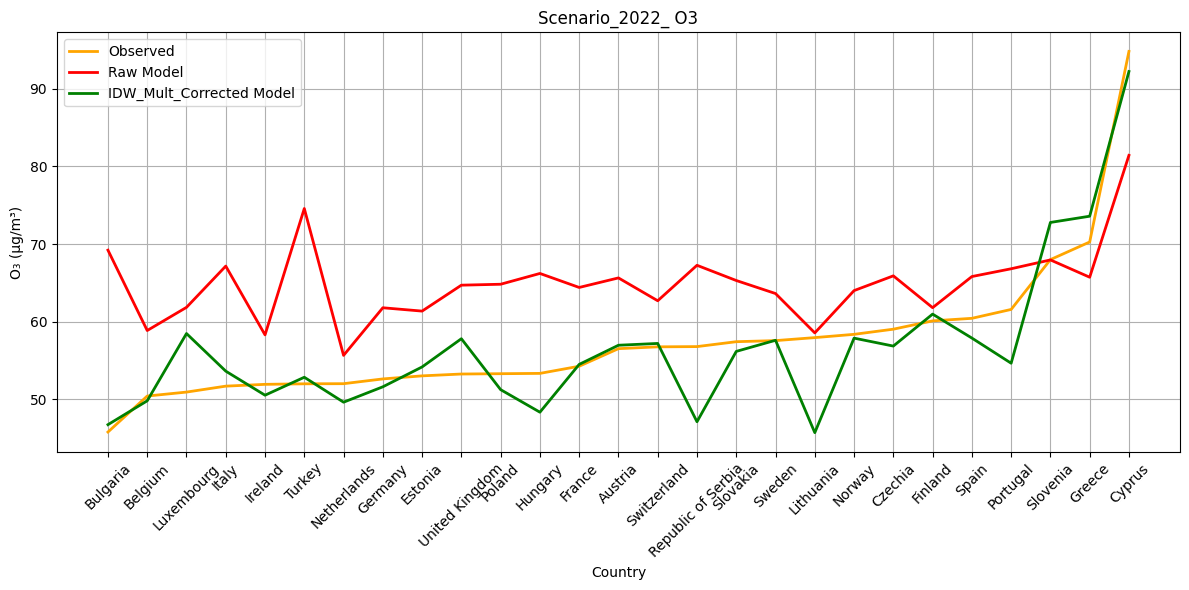


===== PERFORMANCE =====
RMSE Raw: 10.35
RMSE Corrected: 4.17
Bias Raw: 7.45
Bias Corrected: -0.86
RMSE Improvement: 59.74%


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# ======================================================
# 1. LOAD MODELS
# ======================================================
# Bias-corrected model
ds_corr = xr.open_dataset("Scen_2024_NKUA_O3_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_corr["lon"].values
lat = ds_corr["lat"].values

model_corr = ds_corr["SURF_ug_O3"].values
if model_corr.ndim == 3:
    model_corr = model_corr[0]

ds_corr.close()

# Raw model (before correction)
ds_raw = xr.open_dataset("EMEP_yearly_2024.nc")

model_raw = ds_raw["SURF_ug_O3"].values
if model_raw.ndim == 3:
    model_raw = model_raw[0]

ds_raw.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_O3_2024.csv")

geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# ======================================================
# 3. ASSIGN COUNTRIES (NO DOWNLOAD)
# ======================================================
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
world = world.to_crs("EPSG:4326")

gdf = gpd.sjoin(gdf, world[["geometry", "ADMIN"]], how="left", predicate="within")
gdf.rename(columns={"ADMIN": "Country"}, inplace=True)

# ======================================================
# 4. MAP STATIONS TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

model_corr_vals = []
model_raw_vals = []

for _, row in gdf.iterrows():
    j, i = find_idx(row["Longitude"], row["Latitude"])
    model_corr_vals.append(model_corr[j, i])
    model_raw_vals.append(model_raw[j, i])

gdf["Model_Corrected"] = model_corr_vals
gdf["Model_Raw"] = model_raw_vals

# ======================================================
# 5. GROUP BY COUNTRY
# ======================================================
grouped = gdf.groupby("Country")[["Average", "Model_Raw", "Model_Corrected"]].mean()

# remove stations without country
grouped = grouped.dropna()

# sort for better visualization
grouped = grouped.sort_values("Average")

# ======================================================
# 6. PLOT
# ======================================================
x = np.arange(len(grouped))

plt.figure(figsize=(12, 6))

plt.plot(x, grouped["Average"], label="Observed", linewidth=2, color='orange')
plt.plot(x, grouped["Model_Raw"], label="Raw Model", linewidth=2, color='red')
plt.plot(x, grouped["Model_Corrected"], label="IDW_Mult_Corrected Model", linewidth=2, color='green')

plt.xticks(x, grouped.index, rotation=45)

plt.xlabel("Country")
plt.ylabel("O₃ (μg/m³)")
plt.title("Scenario_2022_ O3")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ======================================================
# 7. PERFORMANCE METRICS
# ======================================================
obs = grouped["Average"].values
raw = grouped["Model_Raw"].values
corr = grouped["Model_Corrected"].values

# RMSE
rmse_raw = np.sqrt(np.mean((raw - obs)**2))
rmse_corr = np.sqrt(np.mean((corr - obs)**2))

# Bias
bias_raw = np.mean(raw - obs)
bias_corr = np.mean(corr - obs)

print("\n===== PERFORMANCE =====")
print(f"RMSE Raw: {rmse_raw:.2f}")
print(f"RMSE Corrected: {rmse_corr:.2f}")
print(f"Bias Raw: {bias_raw:.2f}")
print(f"Bias Corrected: {bias_corr:.2f}")

# improvement %
improvement = 100 * (rmse_raw - rmse_corr) / rmse_raw
print(f"RMSE Improvement: {improvement:.2f}%")

# $NO_2$

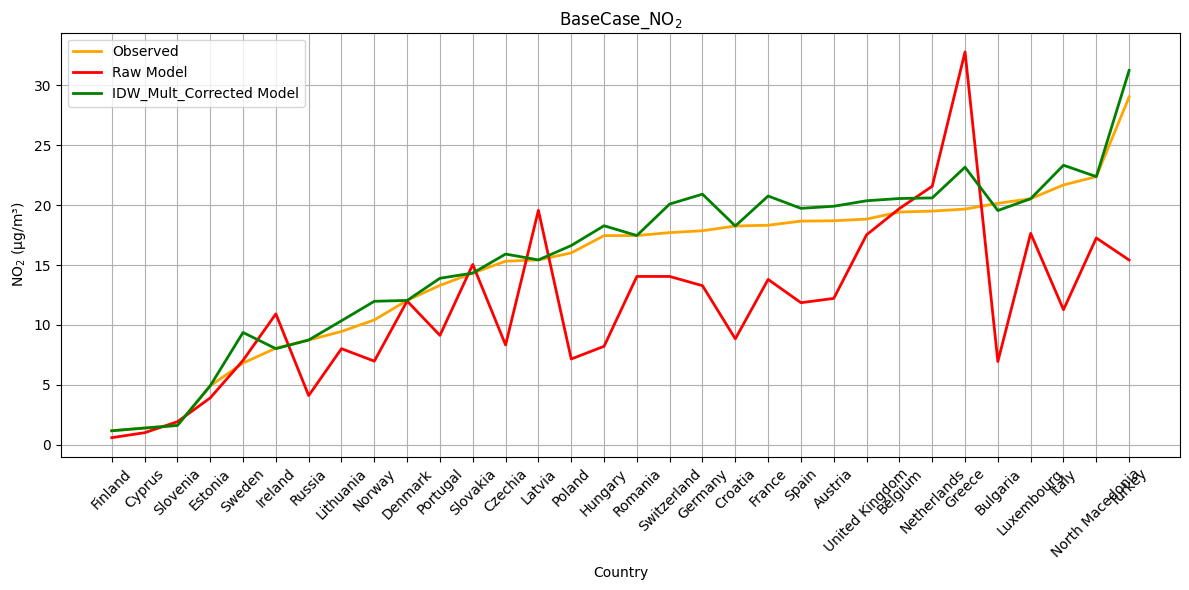


===== PERFORMANCE =====
RMSE Raw: 6.17
RMSE Corrected: 1.37
Bias Raw: -3.20
Bias Corrected: 0.88
RMSE Improvement: 77.78%


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# ======================================================
# 1. LOAD MODELS
# ======================================================
# Bias-corrected model
ds_corr = xr.open_dataset("BaseCase_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_corr["lon"].values
lat = ds_corr["lat"].values

model_corr = ds_corr["SURF_ug_NO2"].values
if model_corr.ndim == 3:
    model_corr = model_corr[0]

ds_corr.close()

# Raw model (before correction)
ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")

model_raw = ds_raw["SURF_ug_NO2"].values
if model_raw.ndim == 3:
    model_raw = model_raw[0]

ds_raw.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2015.csv")

geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# ======================================================
# 3. ASSIGN COUNTRIES (NO DOWNLOAD)
# ======================================================
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
world = world.to_crs("EPSG:4326")

gdf = gpd.sjoin(gdf, world[["geometry", "ADMIN"]], how="left", predicate="within")
gdf.rename(columns={"ADMIN": "Country"}, inplace=True)

# ======================================================
# 4. MAP STATIONS TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

model_corr_vals = []
model_raw_vals = []

for _, row in gdf.iterrows():
    j, i = find_idx(row["Longitude"], row["Latitude"])
    model_corr_vals.append(model_corr[j, i])
    model_raw_vals.append(model_raw[j, i])

gdf["Model_Corrected"] = model_corr_vals
gdf["Model_Raw"] = model_raw_vals

# ======================================================
# 5. GROUP BY COUNTRY
# ======================================================
grouped = gdf.groupby("Country")[["Average", "Model_Raw", "Model_Corrected"]].mean()

# remove stations without country
grouped = grouped.dropna()

# sort for better visualization
grouped = grouped.sort_values("Average")

# ======================================================
# 6. PLOT
# ======================================================
x = np.arange(len(grouped))

plt.figure(figsize=(12, 6))

plt.plot(x, grouped["Average"], label="Observed", linewidth=2, color='orange')
plt.plot(x, grouped["Model_Raw"], label="Raw Model", linewidth=2, color='red')
plt.plot(x, grouped["Model_Corrected"], label="IDW_Mult_Corrected Model", linewidth=2, color='green')

plt.xticks(x, grouped.index, rotation=45)

plt.xlabel("Country")
plt.ylabel("NO$_2$ (μg/m³)")
plt.title("BaseCase_NO$_2$")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ======================================================
# 7. PERFORMANCE METRICS
# ======================================================
obs = grouped["Average"].values
raw = grouped["Model_Raw"].values
corr = grouped["Model_Corrected"].values

# RMSE
rmse_raw = np.sqrt(np.mean((raw - obs)**2))
rmse_corr = np.sqrt(np.mean((corr - obs)**2))

# Bias
bias_raw = np.mean(raw - obs)
bias_corr = np.mean(corr - obs)

print("\n===== PERFORMANCE =====")
print(f"RMSE Raw: {rmse_raw:.2f}")
print(f"RMSE Corrected: {rmse_corr:.2f}")
print(f"Bias Raw: {bias_raw:.2f}")
print(f"Bias Corrected: {bias_corr:.2f}")

# improvement %
improvement = 100 * (rmse_raw - rmse_corr) / rmse_raw
print(f"RMSE Improvement: {improvement:.2f}%")

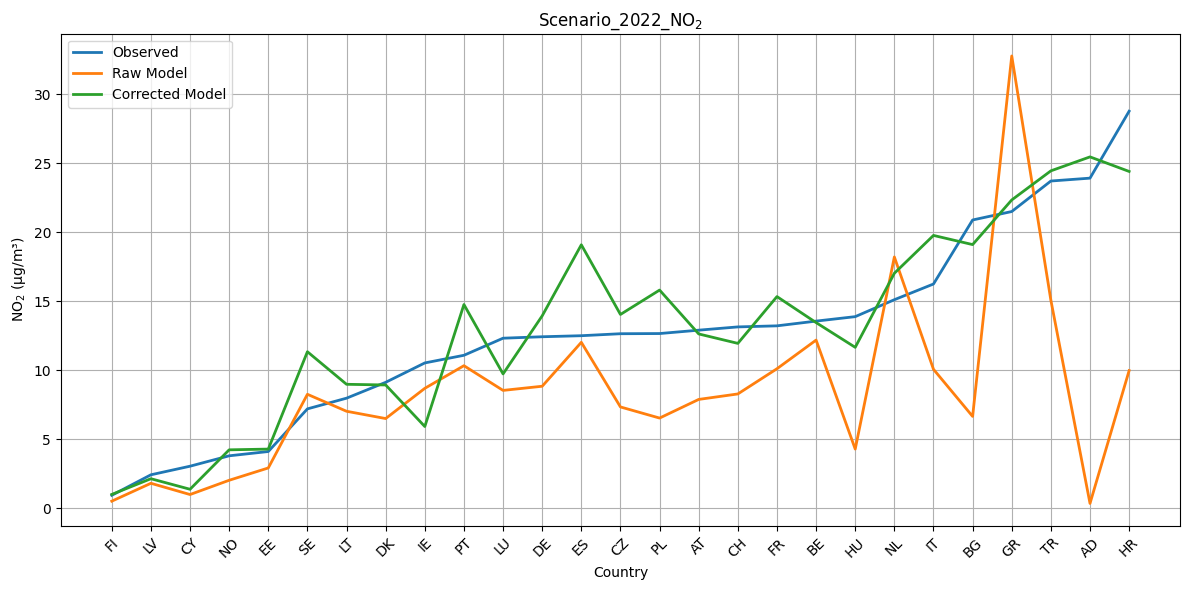


===== PERFORMANCE =====
RMSE Raw: 7.77
RMSE Corrected: 2.53
Bias Raw: -4.13
Bias Corrected: 0.50
RMSE Improvement: 67.39%


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_corr = xr.open_dataset("Scen_2022_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_corr["lon"].values
lat = ds_corr["lat"].values

model_corr = ds_corr["SURF_ug_NO2"].values
if model_corr.ndim == 3:
    model_corr = model_corr[0]

ds_corr.close()

ds_raw = xr.open_dataset("EMEP_yearly_2022.nc")

model_raw = ds_raw["SURF_ug_NO2"].values
if model_raw.ndim == 3:
    model_raw = model_raw[0]

ds_raw.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2022.csv")

# ✔ longitude safety
if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

# ======================================================
# 3. EXTRACT COUNTRY FROM STATION ID
# ======================================================
df["Country"] = df["Station"].str[:2]

# ======================================================
# 4. MAP STATIONS TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

model_corr_vals = []
model_raw_vals = []

for _, row in df.iterrows():
    j, i = find_idx(row["Longitude"], row["Latitude"])
    model_corr_vals.append(model_corr[j, i])
    model_raw_vals.append(model_raw[j, i])

df["Model_Corrected"] = model_corr_vals
df["Model_Raw"] = model_raw_vals

# ======================================================
# 5. GROUP BY COUNTRY
# ======================================================
grouped = df.groupby("Country")[["Average", "Model_Raw", "Model_Corrected"]].mean()

grouped = grouped.dropna()
grouped = grouped.sort_values("Average")

# ======================================================
# 6. PLOT
# ======================================================
x = np.arange(len(grouped))

plt.figure(figsize=(12, 6))

plt.plot(x, grouped["Average"], label="Observed", linewidth=2)
plt.plot(x, grouped["Model_Raw"], label="Raw Model", linewidth=2)
plt.plot(x, grouped["Model_Corrected"], label="Corrected Model", linewidth=2)

plt.xticks(x, grouped.index, rotation=45)

plt.xlabel("Country")
plt.ylabel("NO$_2$ (μg/m³)")
plt.title("Scenario_2022_NO$_2$")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ======================================================
# 7. PERFORMANCE METRICS
# ======================================================
obs = grouped["Average"].values
raw = grouped["Model_Raw"].values
corr = grouped["Model_Corrected"].values

rmse_raw = np.sqrt(np.mean((raw - obs)**2))
rmse_corr = np.sqrt(np.mean((corr - obs)**2))

bias_raw = np.mean(raw - obs)
bias_corr = np.mean(corr - obs)

print("\n===== PERFORMANCE =====")
print(f"RMSE Raw: {rmse_raw:.2f}")
print(f"RMSE Corrected: {rmse_corr:.2f}")
print(f"Bias Raw: {bias_raw:.2f}")
print(f"Bias Corrected: {bias_corr:.2f}")

improvement = 100 * (rmse_raw - rmse_corr) / rmse_raw
print(f"RMSE Improvement: {improvement:.2f}%")

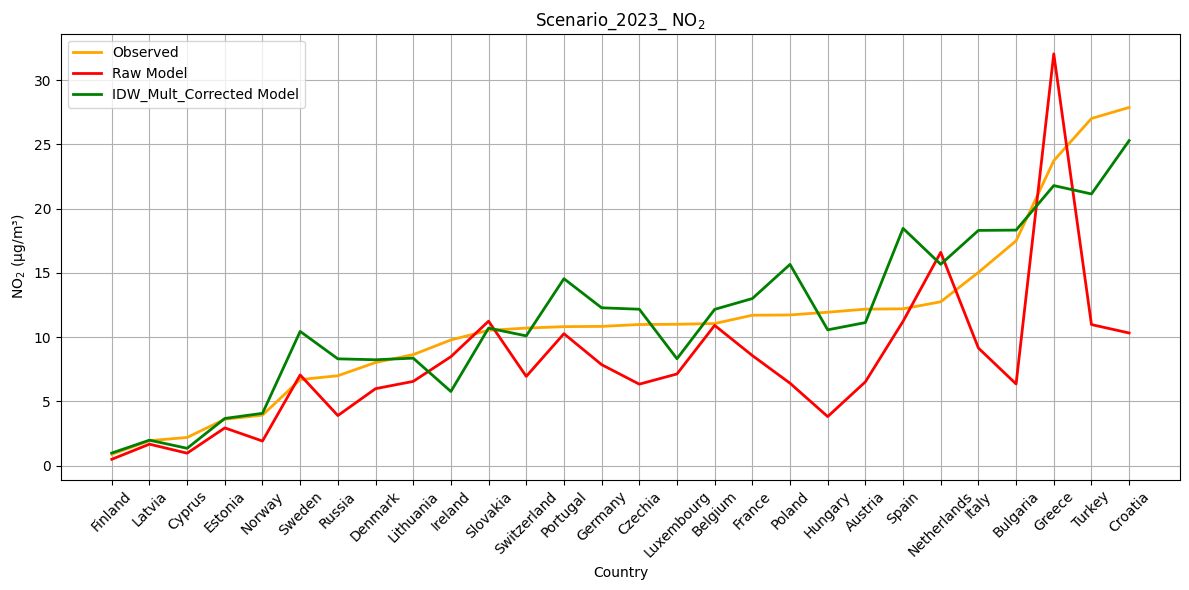


===== PERFORMANCE =====
RMSE Raw: 6.07
RMSE Corrected: 2.56
Bias Raw: -3.20
Bias Corrected: 0.38
RMSE Improvement: 57.87%


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# ======================================================
# 1. LOAD MODELS
# ======================================================
# Bias-corrected model
ds_corr = xr.open_dataset("Scen_2023_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_corr["lon"].values
lat = ds_corr["lat"].values

model_corr = ds_corr["SURF_ug_NO2"].values
if model_corr.ndim == 3:
    model_corr = model_corr[0]

ds_corr.close()

# Raw model (before correction)
ds_raw = xr.open_dataset("EMEP_yearly_2023.nc")

model_raw = ds_raw["SURF_ug_NO2"].values
if model_raw.ndim == 3:
    model_raw = model_raw[0]

ds_raw.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2023.csv")

geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# ======================================================
# 3. ASSIGN COUNTRIES (NO DOWNLOAD)
# ======================================================
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
world = world.to_crs("EPSG:4326")

gdf = gpd.sjoin(gdf, world[["geometry", "ADMIN"]], how="left", predicate="within")
gdf.rename(columns={"ADMIN": "Country"}, inplace=True)

# ======================================================
# 4. MAP STATIONS TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

model_corr_vals = []
model_raw_vals = []

for _, row in gdf.iterrows():
    j, i = find_idx(row["Longitude"], row["Latitude"])
    model_corr_vals.append(model_corr[j, i])
    model_raw_vals.append(model_raw[j, i])

gdf["Model_Corrected"] = model_corr_vals
gdf["Model_Raw"] = model_raw_vals

# ======================================================
# 5. GROUP BY COUNTRY
# ======================================================
grouped = gdf.groupby("Country")[["Average", "Model_Raw", "Model_Corrected"]].mean()

# remove stations without country
grouped = grouped.dropna()

# sort for better visualization
grouped = grouped.sort_values("Average")

# ======================================================
# 6. PLOT
# ======================================================
x = np.arange(len(grouped))

plt.figure(figsize=(12, 6))

plt.plot(x, grouped["Average"], label="Observed", linewidth=2, color='orange')
plt.plot(x, grouped["Model_Raw"], label="Raw Model", linewidth=2, color='red')
plt.plot(x, grouped["Model_Corrected"], label="IDW_Mult_Corrected Model", linewidth=2, color='green')

plt.xticks(x, grouped.index, rotation=45)

plt.xlabel("Country")
plt.ylabel("NO$_2$ (μg/m³)")
plt.title("Scenario_2023_ NO$_2$")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ======================================================
# 7. PERFORMANCE METRICS
# ======================================================
obs = grouped["Average"].values
raw = grouped["Model_Raw"].values
corr = grouped["Model_Corrected"].values

# RMSE
rmse_raw = np.sqrt(np.mean((raw - obs)**2))
rmse_corr = np.sqrt(np.mean((corr - obs)**2))

# Bias
bias_raw = np.mean(raw - obs)
bias_corr = np.mean(corr - obs)

print("\n===== PERFORMANCE =====")
print(f"RMSE Raw: {rmse_raw:.2f}")
print(f"RMSE Corrected: {rmse_corr:.2f}")
print(f"Bias Raw: {bias_raw:.2f}")
print(f"Bias Corrected: {bias_corr:.2f}")

# improvement %
improvement = 100 * (rmse_raw - rmse_corr) / rmse_raw
print(f"RMSE Improvement: {improvement:.2f}%")

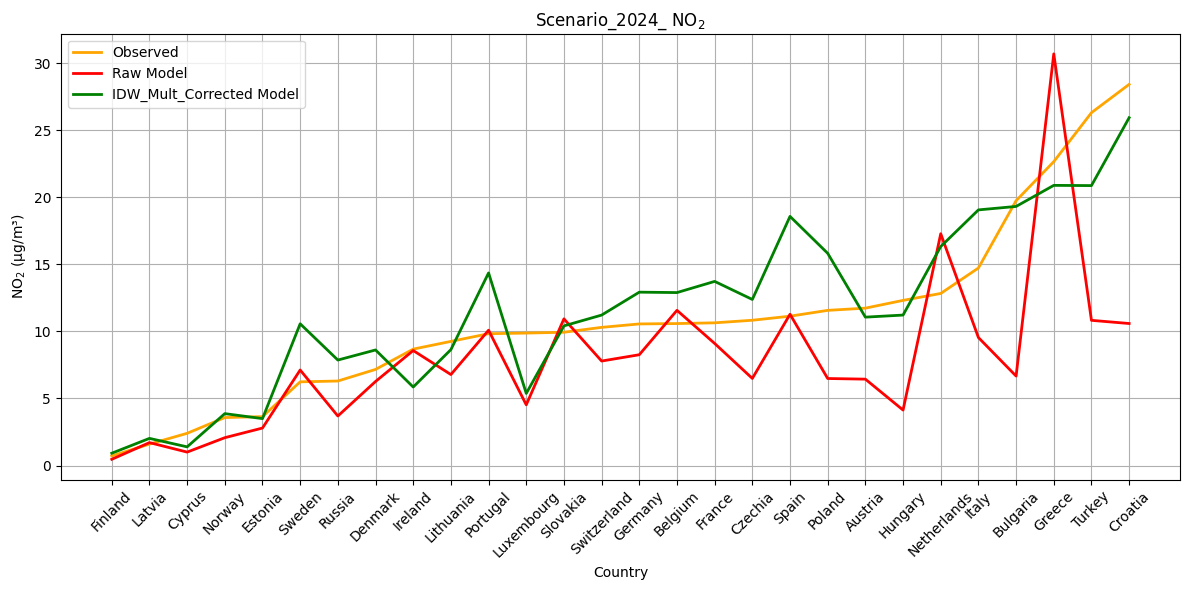


===== PERFORMANCE =====
RMSE Raw: 6.11
RMSE Corrected: 2.95
Bias Raw: -2.87
Bias Corrected: 0.79
RMSE Improvement: 51.75%


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# ======================================================
# 1. LOAD MODELS
# ======================================================
# Bias-corrected model
ds_corr = xr.open_dataset("Scen_2024_NKUA_NO2_CSA.Cell.Mult.IDW_CORR_YEARLY.nc")

lon = ds_corr["lon"].values
lat = ds_corr["lat"].values

model_corr = ds_corr["SURF_ug_NO2"].values
if model_corr.ndim == 3:
    model_corr = model_corr[0]

ds_corr.close()

# Raw model (before correction)
ds_raw = xr.open_dataset("EMEP_yearly_2024.nc")

model_raw = ds_raw["SURF_ug_NO2"].values
if model_raw.ndim == 3:
    model_raw = model_raw[0]

ds_raw.close()

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_NO2_2024.csv")

geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# ======================================================
# 3. ASSIGN COUNTRIES (NO DOWNLOAD)
# ======================================================
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)
world = world.to_crs("EPSG:4326")

gdf = gpd.sjoin(gdf, world[["geometry", "ADMIN"]], how="left", predicate="within")
gdf.rename(columns={"ADMIN": "Country"}, inplace=True)

# ======================================================
# 4. MAP STATIONS TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

model_corr_vals = []
model_raw_vals = []

for _, row in gdf.iterrows():
    j, i = find_idx(row["Longitude"], row["Latitude"])
    model_corr_vals.append(model_corr[j, i])
    model_raw_vals.append(model_raw[j, i])

gdf["Model_Corrected"] = model_corr_vals
gdf["Model_Raw"] = model_raw_vals

# ======================================================
# 5. GROUP BY COUNTRY
# ======================================================
grouped = gdf.groupby("Country")[["Average", "Model_Raw", "Model_Corrected"]].mean()

# remove stations without country
grouped = grouped.dropna()

# sort for better visualization
grouped = grouped.sort_values("Average")

# ======================================================
# 6. PLOT
# ======================================================
x = np.arange(len(grouped))

plt.figure(figsize=(12, 6))

plt.plot(x, grouped["Average"], label="Observed", linewidth=2, color='orange')
plt.plot(x, grouped["Model_Raw"], label="Raw Model", linewidth=2, color='red')
plt.plot(x, grouped["Model_Corrected"], label="IDW_Mult_Corrected Model", linewidth=2, color='green')

plt.xticks(x, grouped.index, rotation=45)

plt.xlabel("Country")
plt.ylabel("NO$_2$ (μg/m³)")
plt.title("Scenario_2024_ NO$_2$")

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# ======================================================
# 7. PERFORMANCE METRICS
# ======================================================
obs = grouped["Average"].values
raw = grouped["Model_Raw"].values
corr = grouped["Model_Corrected"].values

# RMSE
rmse_raw = np.sqrt(np.mean((raw - obs)**2))
rmse_corr = np.sqrt(np.mean((corr - obs)**2))

# Bias
bias_raw = np.mean(raw - obs)
bias_corr = np.mean(corr - obs)

print("\n===== PERFORMANCE =====")
print(f"RMSE Raw: {rmse_raw:.2f}")
print(f"RMSE Corrected: {rmse_corr:.2f}")
print(f"Bias Raw: {bias_raw:.2f}")
print(f"Bias Corrected: {bias_corr:.2f}")

# improvement %
improvement = 100 * (rmse_raw - rmse_corr) / rmse_raw
print(f"RMSE Improvement: {improvement:.2f}%")